<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/CNN/MODEL1_DEMO(shreya_vers)_OF_TEST_CNN_Example_Pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Convolutional Neural Networks in PyTorch

This notebook walks through the application of **convolutional neural networks (CNNs)** using PyTorch.

We will study two examples:

1. A **2D CNN for image classification** on the MNIST handwritten digit dataset.
2. A **1D CNN for time-series classification** on a synthetic signal dataset.

The goal is to mirror the ideas from the NumPy implementation, but now using PyTorch's built-in tools:

- `torch.Tensor`
- `torch.nn.Module`
- `torch.nn.Conv2d`
- `torch.nn.Conv1d`
- `torch.nn.ReLU`
- `torch.nn.MaxPool2d`
- `torch.nn.Linear`
- `torch.optim`
- automatic differentiation through `loss.backward()`

PyTorch handles the tedious backpropagation bookkeeping for us, but the mathematical structure is the same as the NumPy version.



## 1. What is a Convolutional Neural Network?

A fully connected neural network treats each input feature as separate. For images, this ignores spatial structure. A CNN instead uses **filters**, also called **kernels**, that slide across an input and detect local patterns.

For a 2D image, a convolutional layer learns filters that may detect edges, corners, curves, or other local image features.

For a 1D time series, a convolutional layer learns filters that may detect spikes, oscillations, trends, or short temporal patterns.

A typical CNN layer sequence is:

\[
\text{Input} \rightarrow \text{Convolution} \rightarrow \text{Activation} \rightarrow \text{Pooling} \rightarrow \text{Dense Layers} \rightarrow \text{Prediction}.
\]

In PyTorch, these operations are represented as neural network layers.



## 2. Imports and Reproducibility

We will use PyTorch for neural network layers and training, NumPy for data generation, and Matplotlib for visualization.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import sympy
import sympy.core          # force submodule onto the namespace
import sympy.core.symbol
import torch               # now import torch

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split

import importlib
sympy.core = importlib.import_module("sympy.core")
sympy.core.symbol = importlib.import_module("sympy.core.symbol")
print(hasattr(sympy, 'core'))

# Optional imports for MNIST.
# If torchvision is not installed, the synthetic time-series example will still run.

try:
    import torchvision
    import torchvision.transforms as transforms
    TORCHVISION_AVAILABLE = True
except ImportError:
    TORCHVISION_AVAILABLE = False

np.random.seed(42)
torch.manual_seed(42) #42

# Use a GPU if available. Otherwise, use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)



## 3. Helper Function: Training Loop

The same basic PyTorch training loop will be used for both the image example and the time-series example.

For each epoch:

1. Load a mini-batch.
2. Compute predictions.
3. Compute the loss.
4. Clear previous gradients.
5. Backpropagate using `loss.backward()`.
6. Update parameters using the optimizer.

For classification, we will use `nn.CrossEntropyLoss()`. This loss combines:

- a softmax operation, and
- the negative log-likelihood loss.

Therefore, our models should output raw scores, also called **logits**, not softmax probabilities.


In [45]:
def train_classifier(model, train_loader, test_loader=None, epochs=5,
                     learning_rate=1e-3, verbose=True):
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=1, eta_min=1e-5
)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        correct    = 0
        total      = 0

        # Change your DataLoader loop inside train_classifier to unpack three items:
        for X_batch, demog_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            demog_batch = demog_batch.to(device)
            y_batch = y_batch.to(device)

            # Augmentations (Only apply noise/scaling to time-series data, not demographics!)
            X_batch = X_batch + 0.05 * torch.randn_like(X_batch)
            X_batch = X_batch * (0.8 + 0.4 * torch.rand(1, device=device))

            optimizer.zero_grad()

            # Pass both inputs to the fusion model
            logits = model(X_batch, demog_batch)


            loss = criterion(logits, y_batch)
            loss.backward() # Backpropagation
            optimizer.step() # Optimizer step

            b = X_batch.shape[0] # Get batch size
            total_loss += loss.item() * b
            correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            total += b # Accumulate total samples processed

        scheduler.step()

        train_loss = total_loss / total
        train_acc  = correct / total
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)

        if test_loader is not None:
            test_loss, test_acc = evaluate_classifier(model, test_loader, criterion)
            history["test_loss"].append(test_loss)
            history["test_acc"].append(test_acc)
            if verbose:
                print(
                    f"Epoch {epoch+1}/{epochs}: "
                    f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
                    f"test loss={test_loss:.4f}, test acc={test_acc:.4f}, "
                    f"lr={optimizer.param_groups[0]['lr']:.2e}"
                )
        else:
            if verbose:
                print(
                    f"Epoch {epoch+1}/{epochs}: "
                    f"train loss={train_loss:.4f}, train acc={train_acc:.4f}, "
                    f"lr={optimizer.param_groups[0]['lr']:.2e}"
                )

    return history


def evaluate_classifier(model, data_loader, criterion=None):
    model.eval()
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, demog_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            demog_batch = demog_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch, demog_batch)
            loss = criterion(logits, y_batch)

            b = X_batch.shape[0]
            total_loss += loss.item() * b
            correct += (torch.argmax(logits, dim=1) == y_batch).sum().item()
            total += b

    return total_loss / total, correct / total


## 4. Helper Function: Plot Training Curves


In [ ]:

def plot_history(history, title="Training History"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    if len(history["test_loss"]) > 0:
        plt.plot(epochs, history["test_loss"], label="test loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + ": Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_acc"], label="train accuracy")
    if len(history["test_acc"]) > 0:
        plt.plot(epochs, history["test_acc"], label="test accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + ": Accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()



# Part II: A 1D CNN for Time-Series Classification

CNNs are not only for images. A 1D CNN can be applied to sequential data such as:

- sensor measurements,
- financial signals,
- ECG or EEG recordings,
- audio waveforms,
- machine monitoring data,
- traffic or demand data.

A 1D convolutional layer slides filters along the time axis.

For PyTorch `nn.Conv1d`, the input shape is:

\[
N \times C \times L,
\]

where:

- `N` is the batch size,
- `C` is the number of input channels,
- `L` is the sequence length.

For a single univariate time series, `C = 1`.



## 10. Generate a Synthetic Time-Series Dataset

We will create a three-class time-series classification problem.

Each signal has length 100.

The classes are:

- Class 0: low-frequency sine wave,
- Class 1: high-frequency sine wave,
- Class 2: square-wave-like signal.

Noise is added so the classification task is not completely trivial.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

In [42]:
from re import X
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks

ECG_data_1K = np.load('ECG_waveforms_1K.npy')
ECG_summary_1K = np.load('ECG_metrics_1K.npy')
Echo_5K = pd.read_csv('EchoNext_EchoData_5K.csv')

#labels
labels = Echo_5K['shd_moderate_or_greater_flag']
negative = labels==0
positive = labels==1


#initial definitions - ECGs
y_ts = np.array(labels[:1000])
X = ECG_data_1K[:1000]
X_ts = np.swapaxes(X, 1, 2)
print(X_ts.shape)
print(y_ts.shape)


#initial definitions - metrics
y_metric = np.array(labels[:1000])
demog_metric = Echo_5K[['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']]
demog_metric = np.array(demog_metric[:1000])
print(demog_metric[50])


(1000, 12, 2500)
(1000,)
[64 'male' 'white' 77 77.0 156.0 76 405]



## 11. Visualize Example Time Series


In [ ]:

'''
plt.figure(figsize=(10, 5))
for class_label in range(3):
    idx = np.where(y_ts == class_label)[0][0]
    plt.plot(t, X_ts[idx, 0], label=f"Class {class_label}")

plt.xlabel("Time")
plt.ylabel("Signal value")
plt.title("Example Time Series from Each Class")
plt.grid(True)
plt.legend()
plt.show()
'''



## 12. Create PyTorch DataLoaders for Time Series


In [ ]:

'''
X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32, device = device)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long, device = device)


ts_dataset = TensorDataset(X_ts_tensor, y_ts_tensor)

train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True) #change batch size
batch = next(iter(ts_train_loader))
print(batch[0].shape)

ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

print("Time-series training samples:", len(ts_train_dataset))
print("Time-series test samples:", len(ts_test_dataset))
'''


In [48]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# =====================================================================
# 1. PREPROCESSING THE DEMOGRAPHIC DATA
# =====================================================================

# Convert your raw demographic array/list into a clean Pandas DataFrame
columns = ['age_at_ecg', 'sex', 'race_ethnicity',
                      'ventricular_rate', 'atrial_rate', 'pr_interval',
                      'qrs_duration', 'qt_corrected']
df_demog = pd.DataFrame(demog_metric, columns=columns)

# One-hot encode the categorical text features ('gender' and 'race')
# dummy_na=True ensures missing strings get their own column for the imputer to see
df_encoded = pd.get_dummies(df_demog, columns=['sex', 'race_ethnicity'], dummy_na=True, drop_first=False)

# All columns in df_encoded are now numerical and should be scaled before imputation.
# The previous `continuous_cols` list was incorrect because 'sex' and 'race_ethnicity'
# no longer exist after one-hot encoding.
scaler = StandardScaler()
# Apply scaler to all columns of the df_encoded DataFrame
df_encoded_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns, index=df_encoded.index) #ask

# Run KNN Imputer across the combined scaled and encoded columns
imputer = KNNImputer(n_neighbors=3) #looks at 3 other rows with similar data and takes their average for the missing value
demographic_clean = imputer.fit_transform(df_encoded_scaled)

# =====================================================================
# 2. PYTORCH TENSOR AND DATA LOADER SETUP
# =====================================================================

# Dynamically pull the exact number of features after one-hot encoding
fused_demog_dim = demographic_clean.shape[1] #ask
print(f"-> Dynamic Demographic Input Dimension: {fused_demog_dim}")

# Convert your underlying arrays straight into PyTorch device tensors
X_ts_tensor = torch.tensor(X_ts, dtype=torch.float32, device=device)
X_demog_tensor = torch.tensor(demographic_clean, dtype=torch.float32, device=device)
y_ts_tensor = torch.tensor(y_ts, dtype=torch.long, device=device)

# Zip all three parallel data structures into one Dataset
ts_dataset = TensorDataset(X_ts_tensor, X_demog_tensor, y_ts_tensor)

# Generate reproducible train/test splits
train_size = int(0.8 * len(ts_dataset))
test_size = len(ts_dataset) - train_size

ts_train_dataset, ts_test_dataset = random_split(
    ts_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# Build out your final multi-modal DataLoaders
ts_train_loader = DataLoader(ts_train_dataset, batch_size=32, shuffle=True)
ts_test_loader = DataLoader(ts_test_dataset, batch_size=128, shuffle=False)

-> Dynamic Demographic Input Dimension: 16



## 13. Define a 1D CNN for Time-Series Classification

This model uses:

1. `nn.Conv1d(1, 8, kernel_size=5, padding=2)`
2. `nn.ReLU()`
3. `nn.MaxPool1d(2)`
4. `nn.Conv1d(8, 16, kernel_size=5, padding=2)`
5. `nn.ReLU()`
6. `nn.MaxPool1d(2)`
7. Dense classifier layers

The original sequence length is 100.

After the first max pooling layer, the length becomes 50.

After the second max pooling layer, the length becomes 25.

The final convolutional feature tensor has shape:

\[
16 \times 25.
\]


In [ ]:
'''
class TimeSeriesConvNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1 — compress heavily with large kernel
            nn.Conv1d(in_channels, 4, kernel_size=15, padding=7),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.AvgPool1d(kernel_size=5),   # 2500 → 500

            # Block 2 — compress again
            nn.Conv1d(4, 8,  kernel_size=9,  padding=4),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.AvgPool1d(kernel_size=5),   # 500 → 100

            # Block 3 — final compression
            nn.Conv1d(8, 12, kernel_size=5,  padding=2),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.AvgPool1d(kernel_size=5),   # 100 → 20

            # Block 4 — final compression
            nn.Conv1d(12, 16, kernel_size=3, padding=2),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.AvgPool1d(kernel_size=5),   # 20 → 4


        )
        with torch.no_grad():
            dummy        = torch.zeros(1, in_channels, sequence_length)
            dummy_out    = self.features(dummy)
            flattened_sz = dummy_out.shape[1] * dummy_out.shape[2]

        print(f"Flattened size after conv blocks: {flattened_sz}")

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_sz, 20),   # ← dynamic, never hardcoded
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(20, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


ts_model = TimeSeriesConvNet(sequence_length=2500, num_classes=2)
print(ts_model)
'''

In [53]:
import torch
import torch.nn as nn

class DemographicMLP(nn.Module): #MLP = multilayer perceptron ask
    def __init__(self, input_dim=8, output_dim=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, output_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.mlp(x)


class LateFusionHeartDiseaseModel(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demog_dim=8):
        super().__init__()

        # 1. Time Series Feature Extractor (Modified from your original TimeSeriesConvNet)
        self.ts_features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=15, padding=7),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.AvgPool1d(kernel_size=10),   # 2500 -> 250

            nn.Conv1d(16, 32, kernel_size=9, padding=4),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.AvgPool1d(kernel_size=10),   # 250 -> 25

            nn.Conv1d(32, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.AdaptiveAvgPool1d(1),        # 25 -> 1 (Outputs 32 features)
        )

        # 2. Demographic Feature Extractor
        self.demog_features = DemographicMLP(input_dim=demog_dim, output_dim=16)

        # 3. Final Fusion Classifier
        # Total features = 32 (from TimeSeries) + 16 (from MLP) = 48
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 + 16, num_classes)
        )

    def forward(self, ts_input, demog_input):
        # Extract features from both modalities
        ts_emb = self.ts_features(ts_input)
        ts_emb = torch.flatten(ts_emb, start_dim=1) # Shape: [Batch, 32]

        demog_emb = self.demog_features(demog_input) # Shape: [Batch, 16]

        # Late Fusion: Concatenate the feature vectors
        fused_features = torch.cat((ts_emb, demog_emb), dim=1) # Shape: [Batch, 48]

        # Classify
        logits = self.classifier(fused_features)
        return logits

# Instantiate the model
fusion_model = LateFusionHeartDiseaseModel(sequence_length=2500, num_classes=2)
print(fusion_model)


LateFusionHeartDiseaseModel(
  (ts_features): Sequential(
    (0): Conv1d(12, 16, kernel_size=(15,), stride=(1,), padding=(7,))
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): AvgPool1d(kernel_size=(10,), stride=(10,), padding=(0,))
    (4): Conv1d(16, 32, kernel_size=(9,), stride=(1,), padding=(4,))
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
    (7): AvgPool1d(kernel_size=(10,), stride=(10,), padding=(0,))
    (8): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.5, inplace=False)
    (12): AdaptiveAvgPool1d(output_size=1)
  )
  (demog_features): DemographicMLP(
    (mlp): Sequential(
      (0): Linear(in_features=8, out_features=32, bias=True)
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.3, inplace=False)
      (4): Linear(in_features

In [ ]:
print(next(fusion_model.parameters()).is_cuda)
unique, counts = torch.unique(y_ts_tensor, return_counts=True)
for cls, cnt in zip(unique.tolist(), counts.tolist()):
    print(f"Class {cls}: {cnt} samples ({cnt/len(y_ts_tensor)*100:.1f}%)")


## 14. Train the 1D CNN


Epoch 1/60: train loss=0.6228, train acc=0.6388, test loss=0.6147, test acc=0.6750, lr=9.94e-04
Epoch 2/60: train loss=0.5820, train acc=0.7075, test loss=0.5306, test acc=0.7850, lr=9.76e-04
Epoch 3/60: train loss=0.5550, train acc=0.7362, test loss=0.5021, test acc=0.8050, lr=9.46e-04
Epoch 4/60: train loss=0.5455, train acc=0.7288, test loss=0.4765, test acc=0.8150, lr=9.05e-04
Epoch 5/60: train loss=0.5305, train acc=0.7525, test loss=0.4753, test acc=0.7900, lr=8.55e-04
Epoch 6/60: train loss=0.5369, train acc=0.7350, test loss=0.4845, test acc=0.8100, lr=7.96e-04
Epoch 7/60: train loss=0.5187, train acc=0.7488, test loss=0.4583, test acc=0.8050, lr=7.30e-04
Epoch 8/60: train loss=0.5189, train acc=0.7550, test loss=0.4637, test acc=0.7950, lr=6.58e-04
Epoch 9/60: train loss=0.5049, train acc=0.7625, test loss=0.4709, test acc=0.8050, lr=5.82e-04
Epoch 10/60: train loss=0.4865, train acc=0.7738, test loss=0.4935, test acc=0.7900, lr=5.05e-04
Epoch 11/60: train loss=0.4893, train a

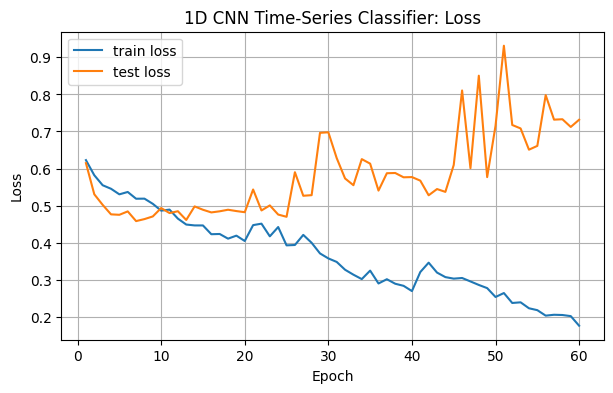

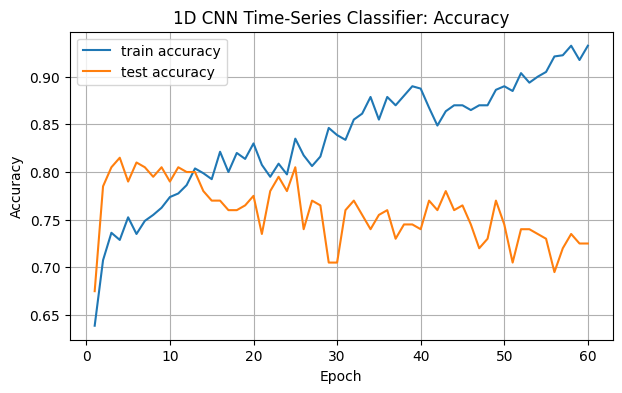

In [54]:
# =====================================================================
# 3. INITIALIZE AND TRAIN THE MODEL
# =====================================================================

# Initialize the model with the correct updated demographic dimension
fusion_model = LateFusionHeartDiseaseModel(
    sequence_length=2500,
    num_classes=2,
    in_channels=12,
    demog_dim=fused_demog_dim
)

# Increase epochs past 5 (e.g., 30) so the model has room to converge
ts_history = train_classifier(
    model=fusion_model,
    train_loader=ts_train_loader,
    test_loader=ts_test_loader,
    epochs=60,
    learning_rate=1e-3
)

plot_history(ts_history, title="1D CNN Time-Series Classifier")



## 15. Inspect Time-Series Predictions


In [ ]:

ts_model.eval()

X_batch, y_batch = next(iter(ts_test_loader))

with torch.no_grad():
    logits = ts_model(X_batch.to(device))
    predictions = torch.argmax(logits, dim=1).cpu()

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.plot(X_batch[i, 0].numpy())
    plt.title(f"True: {y_batch[i].item()}, Pred: {predictions[i].item()}")
    plt.grid(True)

plt.tight_layout()
plt.show()



## 16. Optional: Visualize Learned 1D Filters

The first convolutional layer learns small time-domain filters. Each filter has length 5 in this example.

These learned filters can be thought of as small pattern detectors.


In [ ]:
'''
first_conv = ts_model.features[0]
filters = first_conv.weight.detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(filters.shape[0]):
    plt.subplot(2, 4, i + 1)
    plt.plot(filters[i, 0])
    plt.title(f"Filter {i}")
    plt.grid(True)

plt.tight_layout()
plt.show()
'''



# Summary

This notebook showed two applications of convolutional neural networks in PyTorch.

## 2D CNN for MNIST

A 2D CNN uses filters that slide across image height and width. This is useful for image data because nearby pixels contain meaningful local structure.

## 1D CNN for Time Series

A 1D CNN uses filters that slide along the time axis. This is useful for detecting short temporal patterns such as oscillations, spikes, jumps, or repeated motifs.

## Key PyTorch Ideas

The most important PyTorch components were:

- `nn.Conv2d` for image convolution,
- `nn.Conv1d` for time-series convolution,
- `nn.ReLU` for nonlinear activation,
- `nn.MaxPool2d` and `nn.MaxPool1d` for downsampling,
- `nn.Linear` for dense classification layers,
- `nn.CrossEntropyLoss` for multiclass classification,
- `loss.backward()` for automatic backpropagation,
- `torch.optim.Adam` for parameter updates.

Compared with the NumPy implementation, PyTorch makes the neural network code much shorter because it handles gradients automatically.
